In [81]:
!pip -q install pandas numpy scikit-learn statsmodels matplotlib seaborn

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [83]:
#get the data into a pandas dataframe from my github and put it into a dataframe
url = 'https://raw.githubusercontent.com/pratyushniraula/automobileDataset/main/automobile/imports-85.data'
col_names = ["symboling","normalized-losses","make","fuel-type","aspiration","num-of-doors",
    "body-style","drive-wheels","engine-location","wheel-base","length","width",
    "height","curb-weight","engine-type","num-of-cylinders","engine-size",
    "fuel-system","bore","stroke","compression-ratio","horsepower","peak-rpm",
    "city-mpg","highway-mpg","price"]

df = pd.read_csv(url, names=col_names, na_values='?', header=None)

In [84]:
#checking to see if the data is loaded correctly
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [85]:
#make the numeric columns to numeric data types
numeric_cols = ["symboling","normalized-losses","wheel-base","length","width",
    "height","curb-weight","bore","stroke","compression-ratio","horsepower",
    "peak-rpm","city-mpg","highway-mpg","price","engine-size"]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

#checking for missing values
df.isnull().sum()

# Drop rows with any NaN now that types are coerced
df = df.dropna().reset_index(drop=True)

df.describe()


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,0.735849,121.132075,98.264151,172.413836,65.607547,53.899371,2461.138365,119.226415,3.300126,3.236352,10.161132,95.836478,5113.836478,26.522013,32.081761,11445.729560
std,1.193086,35.651285,5.167416,11.523177,1.947883,2.268761,481.941321,30.460791,0.267336,0.294888,3.889475,30.718583,465.754864,6.097142,6.459189,5877.856195
min,-2.000000,65.000000,86.600000,141.100000,60.300000,49.400000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,15.000000,18.000000,5118.000000
25%,0.000000,94.000000,94.500000,165.650000,64.000000,52.250000,2065.500000,97.000000,3.050000,3.105000,8.700000,69.000000,4800.000000,23.000000,28.000000,7372.000000
50%,1.000000,113.000000,96.900000,172.400000,65.400000,54.100000,2340.000000,110.000000,3.270000,3.270000,9.000000,88.000000,5200.000000,26.000000,32.000000,9233.000000
75%,2.000000,148.000000,100.800000,177.800000,66.500000,55.500000,2809.500000,135.000000,3.560000,3.410000,9.400000,114.000000,5500.000000,31.000000,37.000000,14719.500000
max,3.000000,256.000000,115.600000,202.600000,71.700000,59.800000,4066.000000,258.000000,3.940000,4.170000,23.000000,200.000000,6600.000000,49.000000,54.000000,35056.000000


In [86]:
# Sanity check: no missing values
df.isna().sum().sort_values(ascending=False).head()

symboling            0
normalized-losses    0
highway-mpg          0
city-mpg             0
peak-rpm             0
dtype: int64

In [88]:
display(df.describe(include="all"))
print("\nRows:", len(df))

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,159.000000,159.000000,159,159,159,159,159,159,159,159.000000,...,159.000000,159,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
unique,NaN,NaN,18,2,2,2,5,3,1,NaN,...,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,31,144,132,95,79,105,159,NaN,...,NaN,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.735849,121.132075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.264151,...,119.226415,NaN,3.300126,3.236352,10.161132,95.836478,5113.836478,26.522013,32.081761,11445.729560
std,1.193086,35.651285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.167416,...,30.460791,NaN,0.267336,0.294888,3.889475,30.718583,465.754864,6.097142,6.459189,5877.856195
min,-2.000000,65.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,15.000000,18.000000,5118.000000
25%,0.000000,94.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,3.050000,3.105000,8.700000,69.000000,4800.000000,23.000000,28.000000,7372.000000
50%,1.000000,113.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.900000,...,110.000000,NaN,3.270000,3.270000,9.000000,88.000000,5200.000000,26.000000,32.000000,9233.000000
75%,2.000000,148.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.800000,...,135.000000,NaN,3.560000,3.410000,9.400000,114.000000,5500.000000,31.000000,37.000000,14719.500000



Rows: 159


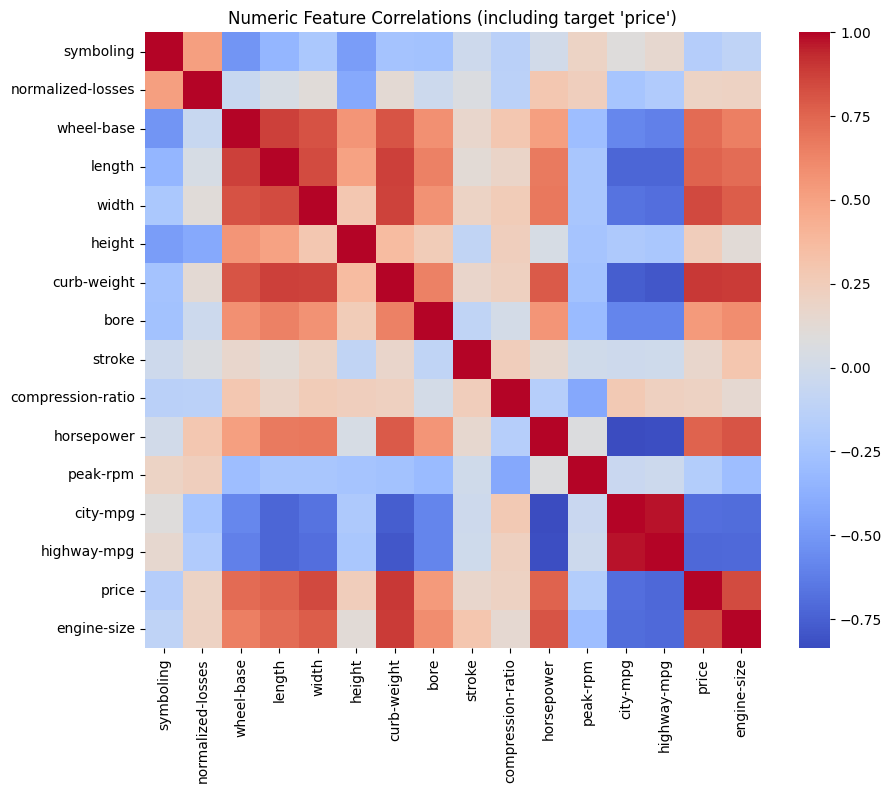

In [97]:
# Simple correlation heatmap for numeric features (including target 'price')
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm", square=True)
plt.title("Numeric Feature Correlations (including target 'price')")
plt.show()

In [98]:
# Select features from correlation heatmap
features = ["engine-size", "horsepower", "curb-weight", "width", "highway-mpg"]

X = df[features]
y = df["price"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((127, 5), (32, 5))

In [99]:
X_train.shape, X_test.shape

((127, 5), (32, 5))

In [110]:
# Collinearity check (VIF)  # req. ✔ interpretation aid
X_vif = sm.add_constant(X_train)
vif_tbl = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_tbl

,feature,VIF
0,const,3890.570824
1,engine-size,7.243427
2,horsepower,5.618284
3,curb-weight,9.142416
4,width,4.134393
5,highway-mpg,4.480732


In [ ]:
#standard gradient descent regressor model

from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(max_iter=1000, tol=1e-3)
sgd.fit(X_train, y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [101]:
sgd.coef_

array([ 1.64378354e+11, -2.43534307e+12, -1.68345086e+12, -2.01020672e+12,
       -8.14049465e+11])

In [102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
y_pred = sgd.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

mse, rmse, mae, r2, evs

(2.0174085207869096e+31,
 np.float64(4491557102817362.0),
 4428462330068120.0,
 -1.1337175965291823e+24,
 -3.1627889849588217e+22)

In [109]:
# Pipeline with StandardScaler + SGDRegressor
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", SGDRegressor(random_state=42))
])

# Hyperparameter grid
param_grid = {
    "regressor__loss": ["squared_error", "huber"],
    "regressor__penalty": ["l2", "l1", "elasticnet"],
    "regressor__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "regressor__l1_ratio": [0.15, 0.5],  # only for elasticnet
    "regressor__learning_rate": ["adaptive"],
    "regressor__eta0": [0.001, 0.01, 0.1],
    "regressor__max_iter": [20000],
    "regressor__tol": [1e-4]
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV RMSE:", np.sqrt(-grid.best_score_))

/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.2/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See http

Best params: {'regressor__alpha': 0.01, 'regressor__eta0': 0.001, 'regressor__l1_ratio': 0.15, 'regressor__learning_rate': 'adaptive', 'regressor__loss': 'squared_error', 'regressor__max_iter': 20000, 'regressor__penalty': 'l2', 'regressor__tol': 0.0001}
Best CV RMSE: 2561.638686402906


/Users/pratyushniraula/Documents/Work/Classes/CS_4372/classpackages/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [111]:
log = pd.DataFrame(grid.cv_results_).sort_values("rank_test_score")
log.to_csv("sgd_tuning_log.csv", index=False)
log[["rank_test_score","mean_test_score","std_test_score","params"]].head(10)

,rank_test_score,mean_test_score,std_test_score,params
108,1,-6.561993e+06,2.329861e+06,"{'regressor__alpha': 0.01, 'regressor__eta0': ..."
114,1,-6.561993e+06,2.329861e+06,"{'regressor__alpha': 0.01, 'regressor__eta0': ..."
110,3,-6.562325e+06,2.327176e+06,"{'regressor__alpha': 0.01, 'regressor__eta0': ..."
116,4,-6.567091e+06,2.316161e+06,"{'regressor__alpha': 0.01, 'regressor__eta0': ..."
120,5,-6.582853e+06,2.315371e+06,"{'regressor__alpha': 0.01, 'regressor__eta0': ..."
126,5,-6.582853e+06,2.315371e+06,"{'regressor__alpha': 0.01, 'regressor__eta0': ..."
122,7,-6.585191e+06,2.313497e+06,"{'regressor__alpha': 0.01, 'regressor__eta0': ..."
128,8,-6.588939e+06,2.307785e+06,"{'regressor__alpha': 0.01, 'regressor__eta0': ..."
78,9,-6.610345e+06,2.323802e+06,"{'regressor__alpha': 0.001, 'regressor__eta0':..."
72,9,-6.610345e+06,2.323802e+06,"{'regressor__alpha': 0.001, 'regressor__eta0':..."


In [108]:
best_model = grid.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

sgd_results = {
    "r2_train": r2_score(y_train, y_pred_train),
    "r2_test": r2_score(y_test, y_pred_test),
    "rmse_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "mae_test": mean_absolute_error(y_test, y_pred_test)
}
sgd_results

{'r2_train': 0.8409024743494291,
 'r2_test': 0.6792980314535237,
 'rmse_test': np.float64(2388.8852809603663),
 'mae_test': 1909.3664612613666}

In [104]:
#-----------------------------------------------------------------------------------
#ordinary linear regression using statsmodels
X_ols = sm.add_constant(X)  # add intercept
ols_model = sm.OLS(y, X_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     149.1
Date:                Tue, 23 Sep 2025   Prob (F-statistic):           6.05e-57
Time:                        23:37:19   Log-Likelihood:                -1464.3
No. Observations:                 159   AIC:                             2941.
Df Residuals:                     153   BIC:                             2959.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -6.254e+04   1.23e+04     -5.068      

In [105]:
# Train/test split for OLS evaluation
X_train_ols, X_test_ols, y_train_ols, y_test_ols = train_test_split(
    X_ols, y, test_size=0.2, random_state=42
)

ols_trained = sm.OLS(y_train_ols, X_train_ols).fit()

y_pred_train_ols = ols_trained.predict(X_train_ols)
y_pred_test_ols  = ols_trained.predict(X_test_ols)

ols_results = {
    "r2_train": r2_score(y_train_ols, y_pred_train_ols),
    "r2_test": r2_score(y_test_ols, y_pred_test_ols),
    "rmse_test": np.sqrt(mean_squared_error(y_test_ols, y_pred_test_ols)),
    "mae_test": mean_absolute_error(y_test_ols, y_pred_test_ols)
}
ols_results

{'r2_train': 0.8422472459643371,
 'r2_test': 0.6694917310372437,
 'rmse_test': np.float64(2425.1334754246636),
 'mae_test': 1917.3796054928641}

In [107]:
# comparing the two models
results_df = pd.DataFrame([sgd_results, ols_results], index=["SGDRegressor", "OLS Regression"])
results_df

,r2_train,r2_test,rmse_test,mae_test
SGDRegressor,0.840902,0.679298,2388.885281,1909.366461
OLS Regression,0.842247,0.669492,2425.133475,1917.379605


In [ ]:
df[['Age', 'Fare']].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)